In [35]:
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt 
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.stem import WordNetLemmatizer
import re
nltk.download('wordnet')
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud, STOPWORDS
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [5]:
df = pd.read_csv('D:\CreativeIT Class work\Datasets\IMDB Dataset.csv').sample(5000, random_state=42)
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\User\AppData\Local\Temp\ipykernel_4580\4040364006.py:1: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv('D:\CreativeIT Class work\Datasets\IMDB Dataset.csv').sample(5000, random_state=42)


,review,sentiment
33553,I really liked this Summerslam due to the look...,positive
9427,Not many television shows appeal to quite as m...,positive
199,The film quickly gets to a major chase scene w...,negative
12447,Jane Austen would definitely approve of this o...,positive
39489,Expectations were somewhat high for me when I ...,negative


In [6]:
df['sentiment'].value_counts()

sentiment
positive    2519
negative    2481
Name: count, dtype: int64

We can use just like the following code.
```
pos_data = df[df['sentiment'] == 'positive']["review"]
neg_data = df[df['sentiment'] == 'negative']["review"]
```

In [ ]:
# pos_data = list(df[df['sentiment'] == 'positive']["review"])
# neg_data = list(df[df['sentiment'] == 'negative']["review"])

In [23]:
pos_data = df[df['sentiment'] == 'positive']["review"]
neg_data = df[df['sentiment'] == 'negative']["review"]

In [24]:
stop_words = set(stopwords.words('english'))

In [ ]:
# visualization

In [27]:
def generate_wordcloud(text_data, title="Word Cloud"):
    wc = WordCloud(
        background_color='white',
        max_words=200,
        min_font_size=10,
        width=800,
        height=400,
        stopwords=stop_words,
        collocations=False  # Prevents duplicate words
    ).generate(text_data)

    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.title(title, fontsize=20)
    plt.axis('off')  # Hide axes for a clean visual
    plt.show()

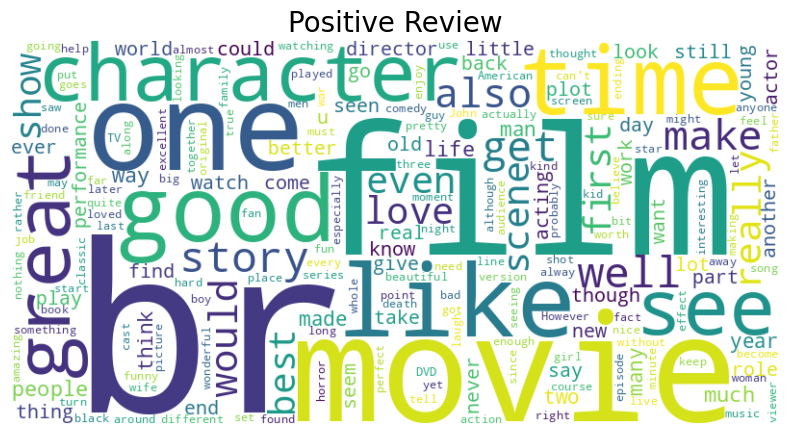

In [28]:
generate_wordcloud(" ".join(pos_data), "Positive Review")

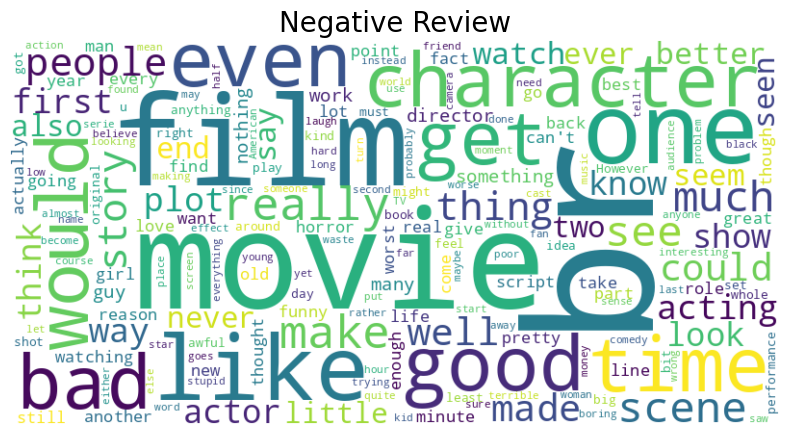

In [29]:
generate_wordcloud(" ".join(neg_data), "Negative Review")

In [31]:
# Text Cleaning
def preprocess_text(text):

  # Remove punctuation and special characters
  text = re.sub(r'[^\w\s]', '', text)
  # digit removal
  text = re.sub(r'\d+', '', text)
  # special character removal
  text=re.sub(r'[^a-zA-Z0-9\s]', '', text)
  text = re.sub(r'\s+', ' ', text)  # Replace multiple spaces with a single space
  # text normalize
  text = re.sub(r"can't" ,"cannot", text)
  text = re.sub(r"won't" ,"will not", text)
  text = re.sub(r"n't" ," not", text)
  text = re.sub(r"'re" ," are", text)
  text = re.sub(r"'s" ," is", text)
  text = re.sub(r"'d" ," would", text)
  text = re.sub(r"'ll" ," will", text)
  text = re.sub(r"'t" ," not", text)
  text = re.sub(r"'ve" ," have", text)
  text = re.sub(r"'m" ," am", text)
  text = re.sub(r"luv" ," love", text)
  text = re.sub(r"love+", "love", text)
  text = re.sub(r"(<br\s*/?>)+", "\n", text)
    

  # Tokenize the text
  tokens = word_tokenize(text)
    
  # Remove stop words
  tokens = [word for word in tokens if word not in stop_words]
    
  # Lemmatize the tokens
  lemmatizer = WordNetLemmatizer()
  lemmatized_tokens = [lemmatizer.lemmatize(token.lower()) for token in tokens]
    
  return " ".join(lemmatized_tokens)

In [32]:
df["cleaned_review"] = df["review"].apply(preprocess_text)

In [ ]:
df.head()

In [33]:
x = df["cleaned_review"]
y = df["sentiment"]

In [36]:
xtrain , xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42) 

In [37]:
# count vec 
c_vectorizer = CountVectorizer()
new_xtrain = c_vectorizer.fit_transform(xtrain)
new_xtrain

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 413221 stored elements and shape (4000, 40885)>

In [38]:
new_xtrain.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(4000, 40885))

In [39]:
# model implementation
dt = DecisionTreeClassifier()
model = dt.fit(new_xtrain, ytrain)

In [40]:
model.score(new_xtrain, ytrain)

1.0

In [41]:
xtest.head()

34234    when come erotic genre im lucky get first minu...
28241    two film useful scaring people god event horiz...
1226     i recently purchased collection one awesome se...
27004    this atrocious waste time no plot the acting f...
35839    seeing gary busey g rated film first nice one ...
Name: cleaned_review, dtype: str

In [42]:
new_xtest= c_vectorizer.transform(xtest)
new_xtest.shape

(1000, 40885)

In [43]:
model.score(new_xtest, ytest)

0.681

In [44]:
# tf-idf vectorizer
tfidf_vectorizer = TfidfVectorizer()
new_xtrain_tfidf = tfidf_vectorizer.fit_transform(xtrain)
new_xtrain_tfidf.shape

(4000, 40885)

In [45]:
model1 = dt.fit(new_xtrain_tfidf, ytrain)
model1.score(new_xtrain_tfidf, ytrain)

1.0

In [46]:
new_xtest= tfidf_vectorizer.transform(xtest)
new_xtest.shape

(1000, 40885)

In [47]:
model1.score(new_xtest, ytest)

0.679